In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()

train_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [3]:
val_size = int(0.2 * len(train_full))
train_size = len(train_full) - val_size
train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()                 
        self.fc1 = nn.Linear(28 * 28, 64)            
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)               
        self.fc2 = nn.Linear(64, 10)                 
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [5]:
model = MNISTClassifier().to(device)
print(model)

MNISTClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) 

In [15]:
def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if train_mode:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if train_mode:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total

In [16]:
epochs = 10
history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(epochs):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - "
          f"loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")
    
test_loss, test_accuracy = run_epoch(test_loader, train_mode=False)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Epoch 1/10 - loss: 0.4344 - accuracy: 0.8796 - val_loss: 0.2275 - val_accuracy: 0.9358
Epoch 2/10 - loss: 0.2353 - accuracy: 0.9319 - val_loss: 0.1692 - val_accuracy: 0.9516
Epoch 3/10 - loss: 0.1897 - accuracy: 0.9436 - val_loss: 0.1524 - val_accuracy: 0.9579
Epoch 4/10 - loss: 0.1634 - accuracy: 0.9517 - val_loss: 0.1304 - val_accuracy: 0.9630
Epoch 5/10 - loss: 0.1457 - accuracy: 0.9569 - val_loss: 0.1181 - val_accuracy: 0.9659
Epoch 6/10 - loss: 0.1353 - accuracy: 0.9590 - val_loss: 0.1197 - val_accuracy: 0.9645
Epoch 7/10 - loss: 0.1240 - accuracy: 0.9620 - val_loss: 0.1149 - val_accuracy: 0.9658
Epoch 8/10 - loss: 0.1200 - accuracy: 0.9624 - val_loss: 0.1089 - val_accuracy: 0.9677
Epoch 9/10 - loss: 0.1127 - accuracy: 0.9643 - val_loss: 0.1032 - val_accuracy: 0.9698
Epoch 10/10 - loss: 0.1074 - accuracy: 0.9654 - val_loss: 0.1029 - val_accuracy: 0.9708

Test Loss: 0.0883
Test Accuracy: 0.9716


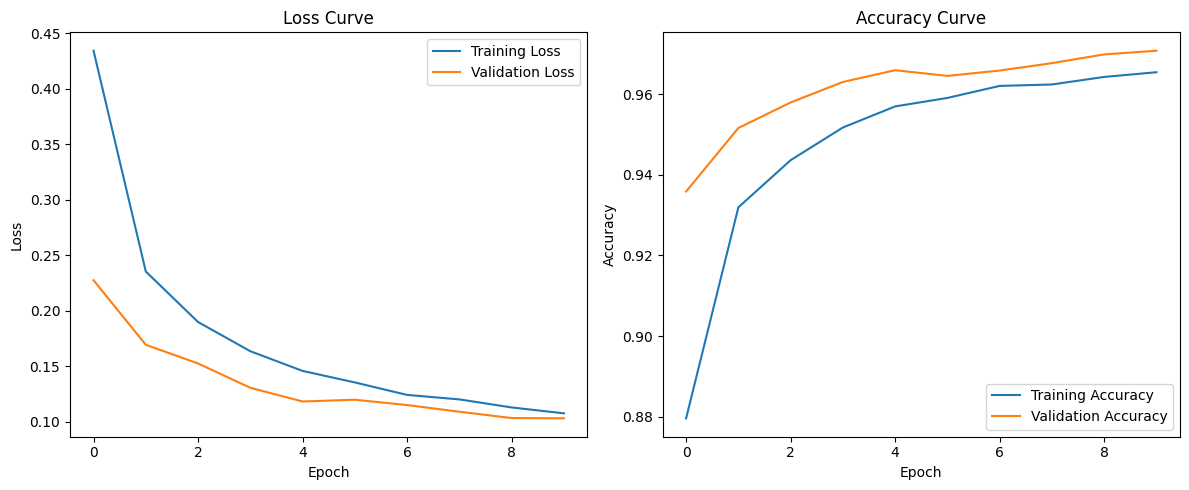

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig('Eval_Curve.png')

plt.tight_layout()
plt.show()